# La Cost Function (Funzione di Costo)

Nel notebook precedente hai provato a scegliere manualmente i parametri `w` e `b` guardando il grafico.

In questo notebook introduciamo un'idea nuova: usare un numero per misurare quanto una retta si avvicina ai dati. Questo numero si chiama **costo**.

## Obiettivi

In questo esercizio dovrai:

1. riprendere il dataset dei salari;
2. usare una funzione `f_wb` per generare previsioni;
3. osservare l'errore tra previsione e valore reale;
4. costruire una funzione costo;
5. confrontare più valori di `w` e `b` usando il costo.

L'idea importante è questa: una retta può sembrare buona a occhio, ma il costo ci dà un modo più preciso per confrontare più tentativi.

## 1. Importare librerie e dati

Per concentrarci sulla cost function, qui il caricamento del dataset è già pronto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('salaries.csv')
x = df['YearsExperience'].to_numpy()
y = df['Salary'].to_numpy()

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 2. Ripartire dal grafico

Prima di parlare di costo, guardiamo di nuovo i dati. Ogni punto rappresenta una persona: sull'asse x ci sono gli anni di esperienza, sull'asse y il salario.

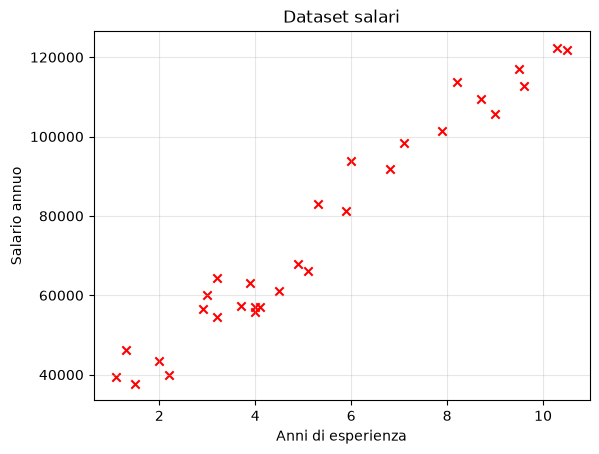

In [2]:
plt.scatter(x, y, color='red', marker='x')
plt.title('Dataset salari')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario annuo')
plt.grid(True, alpha=0.3)
plt.show()

## 3. La funzione del modello

Useremo ancora una retta:

$$f_{w,b}(x) = wx + b$$

Nel codice la funzione si chiama `f_wb`. I parametri `w` e `b` determinano la forma della retta.

In [3]:
def f_wb(x, w, b):
    return w * x + b

## 4. Due rette diverse

Proviamo due coppie diverse di parametri. Il grafico ci aiuta a capire quale retta sembra più vicina ai dati, ma vogliamo arrivare a una misura numerica.

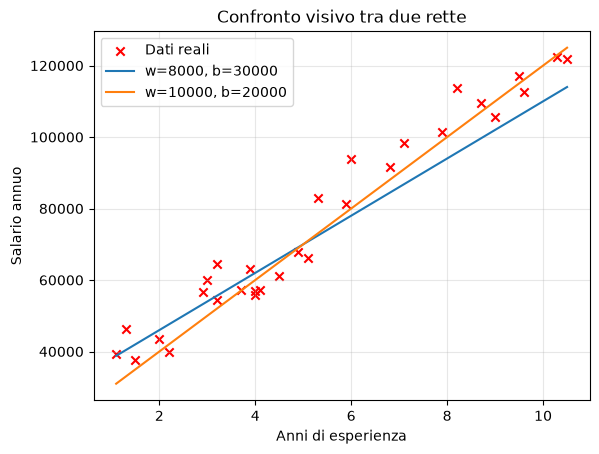

In [4]:
w_1, b_1 = 8000, 30000
w_2, b_2 = 10000, 20000

previsioni_1 = f_wb(x, w_1, b_1)
previsioni_2 = f_wb(x, w_2, b_2)

plt.scatter(x, y, color='red', marker='x', label='Dati reali')
plt.plot(x, previsioni_1, label=f'w={w_1}, b={b_1}')
plt.plot(x, previsioni_2, label=f'w={w_2}, b={b_2}')
plt.title('Confronto visivo tra due rette')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario annuo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Dalla previsione all'errore

Per ogni punto possiamo confrontare:

- il valore reale `y`;
- la previsione prodotta dalla retta `f_wb(x, w, b)`.

La differenza tra previsione e valore reale è l'errore:

$$errore = previsione - valore\ reale$$

Se l'errore è vicino a zero, la previsione è vicina al dato reale.

In [7]:
w = 9000
b = 25000

previsioni = f_wb(x, w, b)
errori = previsioni - y

confronto = pd.DataFrame({
    'anni_esperienza': x,
    'salario_reale': y,
    'previsione': previsioni,
    'errore': errori
})

confronto.head()

,anni_esperienza,salario_reale,previsione,errore
0,1.1,39343.0,34900.0,-4443.0
1,1.3,46205.0,36700.0,-9505.0
2,1.5,37731.0,38500.0,769.0
3,2.0,43525.0,43000.0,-525.0
4,2.2,39891.0,44800.0,4909.0


## 6. Perché elevare l'errore al quadrato?

Gli errori possono essere positivi o negativi:

- errore positivo: la previsione è troppo alta;
- errore negativo: la previsione è troppo bassa.

Se li sommassimo direttamente, errori positivi e negativi potrebbero annullarsi. Per evitarlo, usiamo l'errore al quadrato:

$$errore^2 = (previsione - valore\ reale)^2$$

In questo modo tutti gli errori diventano positivi e gli errori grandi pesano di più.

In [8]:
confronto['errore_quadrato'] = confronto['errore'] ** 2
confronto.head()

,anni_esperienza,salario_reale,previsione,errore,errore_quadrato
0,1.1,39343.0,34900.0,-4443.0,19740249.0
1,1.3,46205.0,36700.0,-9505.0,90345025.0
2,1.5,37731.0,38500.0,769.0,591361.0
3,2.0,43525.0,43000.0,-525.0,275625.0
4,2.2,39891.0,44800.0,4909.0,24098281.0


## 7. La loss function

Ora che abbiamo gli errori al quadrato, introduciamo un concetto preciso: la **loss function**.

La loss function misura l'errore su un **singolo esempio**. Per la regressione lineare usiamo l'errore al quadrato:

$$L(\hat{y}^{(i)}, y^{(i)}) = (\hat{y}^{(i)} - y^{(i)})^2 = (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Dove:
- $\hat{y}^{(i)}$ è la previsione per l'esempio $i$;
- $y^{(i)}$ è il valore reale per l'esempio $i$.

La loss è alta quando la previsione è lontana dal valore reale, bassa quando è vicina.

In [9]:
def loss(y_pred, y_real):
    return (y_pred - y_real) ** 2

# Esempio: loss per il primo punto del dataset
w = 9000
b = 25000
previsione_primo = f_wb(x[0], w, b)
print(f'Anni di esperienza: {x[0]}')
print(f'Salario reale:      {y[0]:.0f}')
print(f'Previsione:         {previsione_primo:.0f}')
print(f'Loss (errore²):     {loss(previsione_primo, y[0]):.0f}')

Anni di esperienza: 1.1
Salario reale:      39343
Previsione:         34900
Loss (errore²):     19740249


## 8. Dalla loss function alla cost function: il MSE

La loss function misura l'errore su un singolo esempio. Ma noi vogliamo una misura che tenga conto di **tutti gli esempi** del dataset.

La risposta naturale è farne la **media**. Questo è esattamente il **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Il MSE è la media delle loss su tutti gli esempi: più è basso, più il modello si avvicina complessivamente ai dati.

### La variante usata in machine learning

In machine learning si usa spesso una versione leggermente diversa, con $\frac{1}{2m}$ invece di $\frac{1}{m}$:

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Il fattore $\frac{1}{2}$ è una **convenienza matematica**: quando si calcola la derivata di $J$ per il gradient descent, il 2 che sale dall'esponente si cancella con il $\frac{1}{2}$, rendendo i calcoli più puliti. La retta migliore rimane la stessa — cambia solo la scala numerica del costo.

Dove:
- `m` è il numero di esempi;
- `f_wb(x, w, b)` è la previsione;
- `y` è il valore reale;
- `J(w,b)` è il costo.

In [10]:
def compute_cost(x, y, w, b):
    m = len(x)
    previsioni = f_wb(x, w, b)
    errori = previsioni - y
    errori_quadrati = errori ** 2
    costo = np.sum(errori_quadrati) / (2 * m)
    return costo

## 8. Confrontare due rette con il costo

Ora possiamo confrontare le due rette viste prima usando un numero, non solo il grafico.

In [11]:
costo_1 = compute_cost(x, y, w_1, b_1)
costo_2 = compute_cost(x, y, w_2, b_2)

print(f'Retta 1 | w={w_1}, b={b_1} | costo={costo_1:.2f}')
print(f'Retta 2 | w={w_2}, b={b_2} | costo={costo_2:.2f}')

Retta 1 | w=8000, b=30000 | costo=29931368.70
Retta 2 | w=10000, b=20000 | costo=20930635.37


## 9. Esercizio: cerca parametri migliori

Modifica solo i valori nella lista `tentativi`. Per ogni coppia `(w, b)`, la cella calcola il costo e disegna la retta corrispondente.

Range consigliati:

- `w` tra `7000` e `12000`;
- `b` tra `15000` e `40000`.

L'obiettivo è trovare una coppia con costo più basso rispetto alle altre.

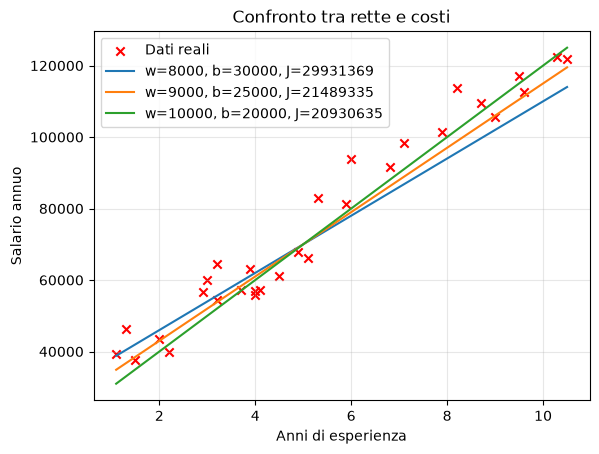

,w,b,costo
2,10000,20000,2.093064e+07
1,9000,25000,2.148934e+07
0,8000,30000,2.993137e+07


In [12]:
tentativi = [
    (8000, 30000),
    (9000, 25000),
    (10000, 20000),
    # aggiungi qui altri tentativi
]

plt.scatter(x, y, color='red', marker='x', label='Dati reali')

risultati = []
for w_tentativo, b_tentativo in tentativi:
    previsioni_tentativo = f_wb(x, w_tentativo, b_tentativo)
    costo_tentativo = compute_cost(x, y, w_tentativo, b_tentativo)
    risultati.append((w_tentativo, b_tentativo, costo_tentativo))
    etichetta = f'w={w_tentativo}, b={b_tentativo}, J={costo_tentativo:.0f}'
    plt.plot(x, previsioni_tentativo, label=etichetta)

plt.title('Confronto tra rette e costi')
plt.xlabel('Anni di esperienza')
plt.ylabel('Salario annuo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame(risultati, columns=['w', 'b', 'costo']).sort_values('costo')

## 10. Guardare come cambia il costo

Per semplificare, fissiamo `b` e facciamo variare solo `w`. In questo modo possiamo vedere come cambia il costo quando la retta diventa più o meno inclinata.

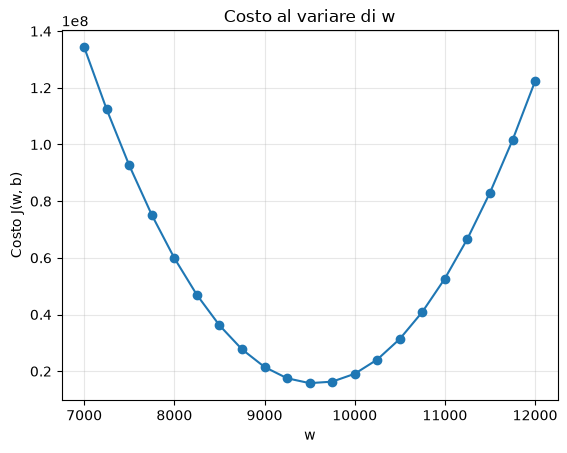

In [13]:
b_fisso = 25000
valori_w = np.arange(7000, 12001, 250)
costi = [compute_cost(x, y, w_corrente, b_fisso) for w_corrente in valori_w]

plt.plot(valori_w, costi, marker='o')
plt.title('Costo al variare di w')
plt.xlabel('w')
plt.ylabel('Costo J(w, b)')
plt.grid(True, alpha=0.3)
plt.show()

## Riepilogo

In questo notebook hai visto che:

- ogni retta produce previsioni diverse;
- l'errore misura la distanza tra previsione e valore reale per ogni punto;
- elevare l'errore al quadrato evita che errori positivi e negativi si annullino;
- la **loss function** misura l'errore su un singolo esempio;
- la **cost function** applica la loss a tutti gli esempi e ne fa la media (**MSE**);
- in machine learning si usa $\frac{1}{2m}$ invece di $\frac{1}{m}$ per comodità nel calcolo del gradient descent;
- scegliere `w` e `b` significa cercare una retta con costo più basso.